In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import yfinance as yf
import datetime as dt
from datetime import datetime
from tabulate import tabulate
import matplotlib.pyplot as plt
from plotly.io import show
from sklearn.model_selection import train_test_split
import warnings

from skfolio import PerfMeasure, RatioMeasure, RiskMeasure
from skfolio.optimization import MeanRisk
from skfolio.preprocessing import prices_to_returns

In [2]:
#Stock lists
stocklist = ["AMZN", "AAPL", "LPL", "CROX", "LLY", "LPLA"]

#Import data
start_date = '2020-01-01'
end_date = datetime.now().strftime('%Y-%m-%d')

stock_data = {}
for stock in stocklist:
    try: 
        stock_data[stock] = yf.download(stock, start=start_date, end=end_date)
        print(f"Data sucessfully retrieved for {stock}.")
    except Exception as e:
        print(f"Error fetching data for {stock}: {e}")
        
close_prices = pd.concat([data['Close'] for data in stock_data.values()], axis = 1)
close_prices.columns = stocklist

print(close_prices.head())

/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1882386356.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1882386356.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Data sucessfully retrieved for AMZN.


[*********************100%***********************]  1 of 1 completed
/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1882386356.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1882386356.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Data sucessfully retrieved for AAPL.
Data sucessfully retrieved for LPL.


[*********************100%***********************]  1 of 1 completed
/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1882386356.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Data sucessfully retrieved for CROX.


[*********************100%***********************]  1 of 1 completed
/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1882386356.py:11: FutureWarning:

YF.download() has changed argument auto_adjust default to True



Data sucessfully retrieved for LLY.


[*********************100%***********************]  1 of 1 completed

Data sucessfully retrieved for LPLA.
                 AMZN       AAPL   LPL       CROX         LLY       LPLA
Date                                                                    
2020-01-02  94.900497  72.400520  7.14  41.750000  122.793129  90.208405
2020-01-03  93.748497  71.696625  6.93  42.080002  122.384445  88.700294
2020-01-06  95.143997  72.267937  6.88  42.410000  122.839561  88.998077
2020-01-07  95.343002  71.928062  6.98  41.610001  123.071732  90.900017
2020-01-08  94.598503  73.085091  6.87  42.680000  124.186287  91.726128


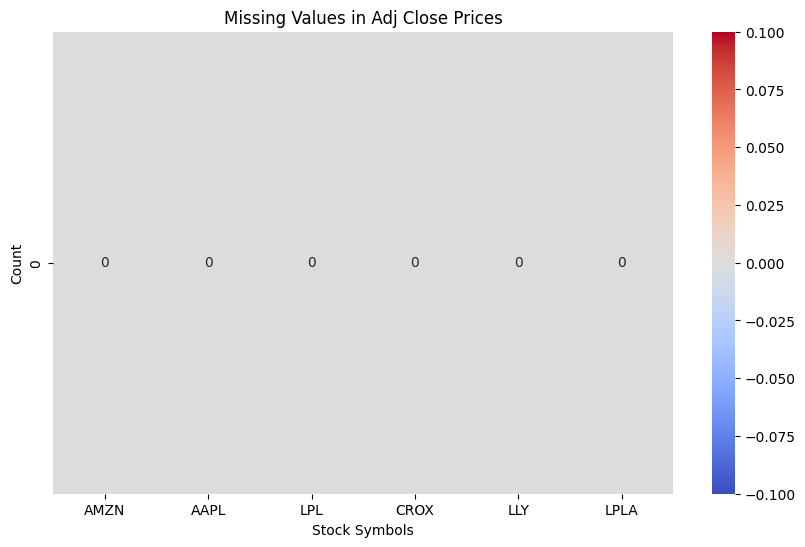

In [3]:
#Calculate the missing values for each column
missing_values_counts = close_prices.isna().sum().to_frame().T

#Visualize
plt.figure(figsize=(10,6))
sns.heatmap(missing_values_counts, cmap='coolwarm', annot=True, fmt='0.0f')
plt.title('Missing Values in Adj Close Prices')
plt.xlabel('Stock Symbols')
plt.ylabel('Count')
plt.show()

0.0009350531377876802
0.0007180659612414826


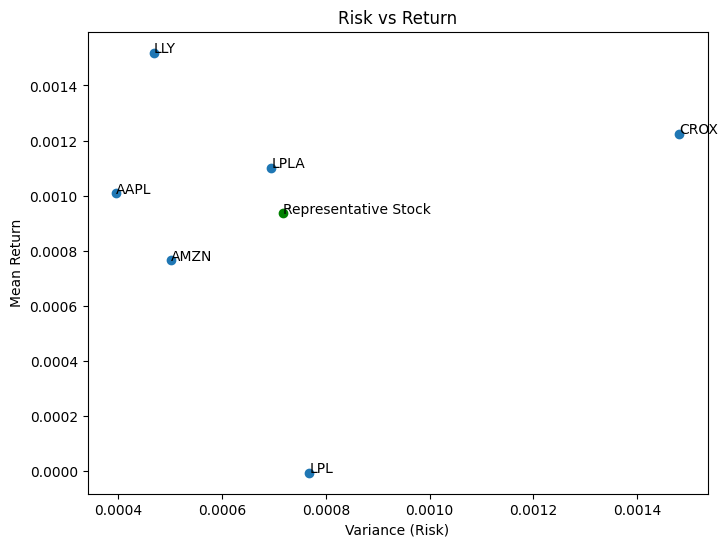

In [4]:
#Calculate the return, mean return,and the variance of the return of each stock 
returns = close_prices.pct_change()
mean_returns = returns.dropna().mean()
returns_var = returns.var()


#Representative stock
rep_return = np.mean(mean_returns)  
rep_variance = np.mean(returns_var)

print(rep_return)
print(rep_variance)

#Visualize

#Annotate all stocks
plt.figure(figsize=(8,6))

plt.scatter(returns_var, mean_returns)

for stock in mean_returns.index:
    plt.annotate(stock, (returns_var[stock], mean_returns[stock]))
    
#Highlight special stocks
plt.scatter(rep_variance, rep_return, color='green')
plt.annotate('Representative Stock', (rep_variance, rep_return))
 
plt.xlabel('Variance (Risk)')
plt.ylabel('Mean Return')
plt.title('Risk vs Return')
plt.show()




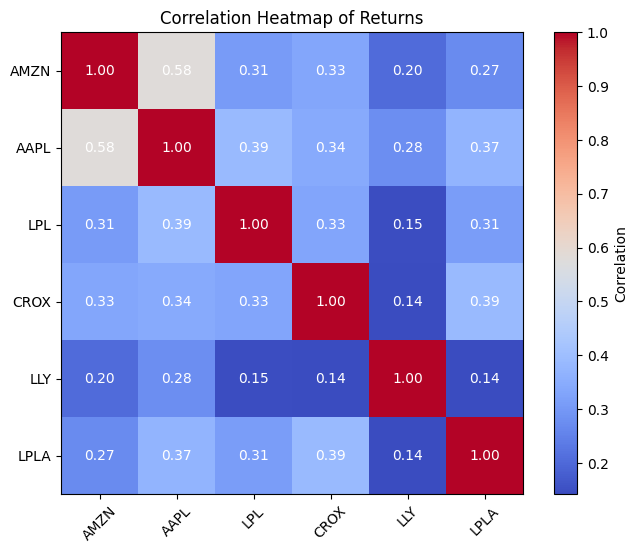

In [5]:
#Covariance and correlation
covariance_matrix = returns.cov()
correlation_matrix = returns.corr()

#Plot heatmap
plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='nearest')

#Add annotations
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha = 'center', va = 'center', color = 'white')
        
plt.colorbar(label = 'Correlation')
plt.title('Correlation Heatmap of Returns')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.show()


In [11]:
# Monte Carlo Simulation

# Initialize the data frame for the weight of each assets
p_ret = []
p_vol = []
p_weights = []

num_assets = len(close_prices.columns)
num_portfolios = 10000

# Generate random portfolios
for _ in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights) 
    p_weights.append(weights)
    
    # Portfolio daily return
    daily_return = np.dot(weights, mean_returns)
    p_ret.append(daily_return)
    
    # Portfolio daily variance
    var = covariance_matrix.mul(weights, axis=0).mul(weights, axis=1).sum().sum()
    daily_sd = np.sqrt(var)
    
    # Annualize daily return and volatility
    ann_return = daily_return * 250
    ann_vol = daily_sd * np.sqrt(250)
    p_vol.append(ann_vol)

# Construct DataFrame for portfolios
data = {'Returns': p_ret, 'Volatility': p_vol}

rf = 0.04
sharpe_ratios = [(r - rf) / v for r, v in zip(p_ret, p_vol)]
data['Sharpe Ratio'] = sharpe_ratios

# Add weights for each asset
for counter, symbol in enumerate(close_prices.columns.tolist()):
    data[symbol + ' weight'] = [w[counter] for w in p_weights]

# Create the DataFrame
portfolios = pd.DataFrame(data)
portfolios.head(10)


,Returns,Volatility,Sharpe Ratio,AMZN weight,AAPL weight,LPL weight,CROX weight,LLY weight,LPLA weight
0,0.000907,0.298809,-0.130830,0.056084,0.086060,0.225877,0.215533,0.134650,0.281796
1,0.000927,0.317910,-0.122907,0.039595,0.273285,0.158916,0.274407,0.015455,0.238342
2,0.001128,0.261742,-0.148513,0.353369,0.011159,0.005367,0.139212,0.324424,0.166469
3,0.000960,0.261949,-0.149035,0.184838,0.026710,0.186284,0.138962,0.270890,0.192317
4,0.000836,0.264425,-0.148110,0.243200,0.207990,0.189192,0.079950,0.085977,0.193690
5,0.000862,0.255529,-0.153165,0.033894,0.288649,0.274183,0.044602,0.232655,0.126017
6,0.000910,0.257012,-0.152094,0.011299,0.258578,0.272389,0.078308,0.308507,0.070919
7,0.001076,0.364089,-0.106908,0.019512,0.049136,0.100904,0.421639,0.109345,0.299464
8,0.001019,0.294906,-0.132180,0.215169,0.214345,0.038817,0.224517,0.061732,0.245419
9,0.000892,0.254405,-0.153724,0.191534,0.111467,0.217872,0.089528,0.229605,0.159993


/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1024714141.py:8: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/2n/lfgz4hr5525103457853j94c0000gn/T/ipykernel_27166/1024714141.py:9: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



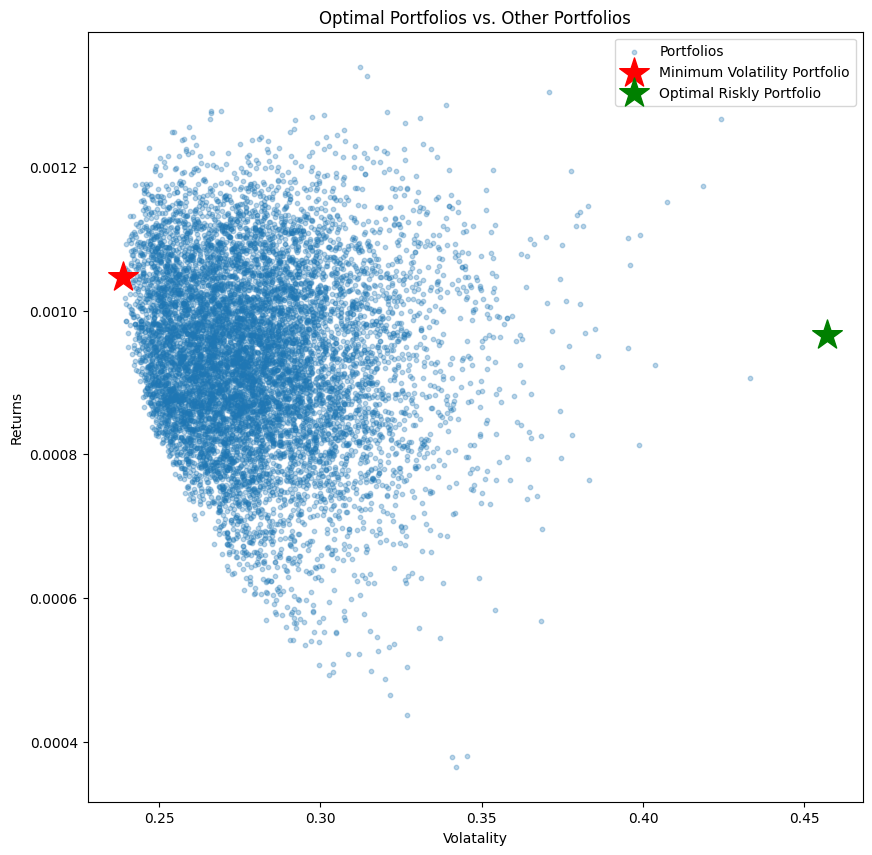

In [13]:
# Plotting the Efficient Frontier
#Define the minimum volatility and the optimal Sharpe ratio portfolios
min_vol_port = portfolios.iloc[portfolios['Volatility'].idxmin()]
optimal_risky_port = portfolios.iloc[portfolios['Sharpe Ratio'].idxmax()]

plt.subplots(figsize=(10, 10))
plt.scatter(portfolios['Volatility'], portfolios['Returns'], marker='o', s=10, alpha=0.3, label='Portfolios')
plt.scatter(min_vol_port[1], min_vol_port[0], color='r', marker='*', s=500, label='Minimum Volatility Portfolio')
plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color='g', marker='*', s=500, label='Optimal Riskly Portfolio')
plt.xlabel('Volatality')
plt.ylabel('Returns')
plt.title('Optimal Portfolios vs. Other Portfolios')
plt.legend()
plt.show()
